***Machine Learning Assignment***
# Predicitng Kenyan Financial Situations
**Done by Junaid, Clyde, Vinit, and Lee**
The basis of this project is to use data from 20,871 Kenyan adults surveyed in 2024 to build a machine learning model that can predict whether a person's financial situation has improved, stayed the same, or worsened, as well as identifying the key factors that drive the financial outcomes in Kenya.

## Table of Contents
- [Project Phases](#project-phases)
- [Data Acquisition](#data-acquisition)
- [Data Preprocessing](#data-preprocessing)
- [Feature Selection](#feature-selection)
- [Model Validation and Testing](#model-validation-and-testing)
- [Data visualization](#data-visualization)

## Project Phases
The project is broken down into the following phases:
1. Data acquisition: the dataset is sourced from Kaggle [https://www.kaggle.com/datasets/davidpbriggs/kenya-finaccess-household-survey-2024](https://www.kaggle.com/datasets/davidpbriggs/kenya-finaccess-household-survey-2024)
2. Data cleaning and preprocessing: missing values are handled, and non-numeric features are encoded for use in models
3. Feature selection: specific features are selected to use during training, primarily through Lasso (L1) regression
4. Model selection and testing: a model (either SVM, ANN, or decision trees) is chosen to use, and it is tested with the data
5. Data visualization: the results of the data and any findings are visualized for presentation

## Data Acquisition
As mentioned before, the data has been pulled from Kaggle: [https://www.kaggle.com/datasets/davidpbriggs/kenya-finaccess-household-survey-2024](https://www.kaggle.com/datasets/davidpbriggs/kenya-finaccess-household-survey-2024). A copy of the dataset it saved within the repository as well.

## Data Preprocessing
This is the first stage of the project. We import the dataset and get a summary of the columns and data we're dealing with.  
From there, we handle any missing values and encode the data for usage in models.

In [1]:
import pandas as pd
import numpy as np

import os
os.environ['PYTHONHASHSEED'] = '42'
import random
random.seed(42)
np.random.seed(42)


# Load the dataset
df = pd.read_excel('finaccess2024_datasprint.xlsx')

print(df.shape)

df.head()

(20871, 28)


,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,...,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,NaN,Without Disability
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,...,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,...,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability
3,Kiambu,Urban,Male,18-25,1,"""Some secondary""",Single/Never Married,10000,Usage,Non-usage,...,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability
4,Murang'a,Urban,Female,18-25,1,Some technical training after secondary school,Single/Never Married,10000,Usage,Non-usage,...,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,NaN,Without Disability


In [2]:
# Locate any columns with missing data
df.isna().sum()

county                      0
location_type               0
Sex                         0
Age                         0
household_size              0
education_level             0
marital_status              0
monthly_income              0
Savings_formal              0
Savings_informal            0
Loan_formal                 0
Loan_informal               0
defaulted                   0
formal_service_use          0
mobile_money_access         0
barriers_mobile_money       0
mobile_ownership_1          0
experienced_shock           0
nfhi_11                     0
nfhi_12                     0
nfhi_13                     0
accessto_13k_1month         0
not_difficult               0
financial_status            0
fl_score                    0
prodsum1                    0
barriers_bank            5734
has_disability              0
dtype: int64

From the above, we can see only one column has missing values: `barriers_bank`.  
`barriers_bank` indicates what barriers a person might have when accessing a bank, such as not being able to afford it, being illegible, difficult access, and so on. We can substitute the missing values with the text `No Barriers` as that makes the most sense.


In [3]:
df.fillna(value={"barriers_bank": "No barrier"}, inplace=True)

print(f"NaN values present in full dataset: {df.isna().sum().sum()}")

df.head()

NaN values present in full dataset: 0


,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,...,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,No barrier,Without Disability
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,...,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,...,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability
3,Kiambu,Urban,Male,18-25,1,"""Some secondary""",Single/Never Married,10000,Usage,Non-usage,...,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability
4,Murang'a,Urban,Female,18-25,1,Some technical training after secondary school,Single/Never Married,10000,Usage,Non-usage,...,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,No barrier,Without Disability


Let's also look out for any mixed data types in the columns.

In [4]:
# Find mixed data types
for column in df.columns:
    col_type = pd.api.types.infer_dtype(df[column])
    if "mixed" in col_type:
        print(f"{column}: {col_type}")

df[['education_level', 'barriers_mobile_money']].head()

education_level: mixed-integer
barriers_mobile_money: mixed-integer


,education_level,barriers_mobile_money
0,Completed technical training after secondary s...,0
1,"""None """,0
2,"""Primary completed""",0
3,"""Some secondary""",0
4,Some technical training after secondary school,0


From the above, we can see that the `education_level` and `barriers_mobile_money` have mixed data types, most likely integers mixed in with the string values.

For the `education_level`, we can remove any columns with an integer in them, as that's probably an outlier. For `barriers_mobile_money`, we can convert all cells with a `0` to `No barriers`, similar to the `bank_barriers` column.

In [5]:
# Handle the education_level column
education_col = df['education_level']
num = pd.to_numeric(education_col, errors='coerce')
is_int = num.notna() & (num % 1 == 0)
df = df.loc[~is_int]

# Handle the barriers_mobile_money column
df.loc[df['barriers_mobile_money'] == 0, 'barriers_mobile_money'] = 'No barrier'

print(df.shape)

df[['education_level', 'barriers_mobile_money']].head()

(20869, 28)


,education_level,barriers_mobile_money
0,Completed technical training after secondary s...,No barrier
1,"""None """,No barrier
2,"""Primary completed""",No barrier
3,"""Some secondary""",No barrier
4,Some technical training after secondary school,No barrier


The marital status columns also has two values we need to remove from the dataset:
- Don't know   (DO NOT READ OUT)
- Refused to Answer(DO NOT READ OUT)

Some people also didn't answer what education level they're in, so we should remove that as well.

In [6]:
invalid_rows = df[
    (df['marital_status'].isin(["Don't know   (DO NOT READ OUT)", "Refused to Answer(DO NOT READ OUT)"])) 
    | (df['education_level'].isin(["\"Refused to Answer (DO NOT READ OUT)\"",'"Don\'t know (DO NOT READ OUT)"','"Other (Specify) "']))
    ].index
df.drop(invalid_rows, inplace=True)

print(df.shape)

# Get the number of unique values in each column
df.nunique()

(20853, 28)


county                    47
location_type              2
Sex                        2
Age                        6
household_size            20
education_level            9
marital_status             4
monthly_income           236
Savings_formal             2
Savings_informal           2
Loan_formal                2
Loan_informal              2
defaulted                  2
formal_service_use         2
mobile_money_access        2
barriers_mobile_money     10
mobile_ownership_1         2
experienced_shock          2
nfhi_11                    2
nfhi_12                    2
nfhi_13                    2
accessto_13k_1month        2
not_difficult              2
financial_status           3
fl_score                   4
prodsum1                  23
barriers_bank             10
has_disability             2
dtype: int64

We can now setup a column transformer using Scikit-Learn to handle encoding the data and preprocessing it.

For all columns which have two or more unique values (excluding the county, prodsum1, and fl_score), we'll use one-hot encoding.

Counties will be encoded using a target encoder. FL_score will use label encoding, as well as financial situation.

In [7]:
# one_hot_cols = [
#     'location_type',
#     'Sex',
#     'Age',
#     'education_level',
#     'marital_status',
#     'Savings_formal',
#     'Savings_informal',
#     'Loan_formal',
#     'Loan_informal',
#     'defaulted',
#     'formal_service_use',
#     'mobile_money_access',
#     'mobile_ownership_1',
#     'experienced_shock',
#     'nfhi_11',
#     'nfhi_12',
#     'nfhi_13',
#     'accessto_13k_1month',
#     'not_difficult',
#     'has_disability',
#     'barriers_mobile_money',
#     'barriers_bank'
# ]
# """Columns to be one-hot encoded"""

# target_cols = ['county']
# """Columns to be encoded using TargetEncoder"""

# num_cols = ['household_size', 'monthly_income']
# """Columns to be scaled using StandardScaler"""

In [8]:
county_col = ['county']

binary_cols = [
    'location_type', 'Sex', 'Savings_formal', 'Savings_informal',
    'Loan_formal', 'Loan_informal', 'defaulted', 'formal_service_use',
    'mobile_money_access', 'mobile_ownership_1', 'experienced_shock',
    'nfhi_11', 'nfhi_12', 'nfhi_13', 'accessto_13k_1month',
    'not_difficult', 'has_disability'
]

ordinal_cols = ['Age', 'education_level', 'fl_score'] 

nominal_cols = ['marital_status', 'barriers_mobile_money', 'barriers_bank']  

numeric_cols = ['household_size', 'monthly_income', 'prodsum1']

In [9]:
binary_maps = {
    'location_type': {'Rural': 0, 'Urban': 1},
    'Sex': {'Female': 0, 'Male': 1},
    'Savings_formal': {'Non-usage': 0, 'Usage': 1},
    'Savings_informal': {'Non-usage': 0, 'Usage': 1},
    'Loan_formal': {'Non-usage': 0, 'Usage': 1},
    'Loan_informal': {'Non-usage': 0, 'Usage': 1},
    'defaulted': {'No': 0, 'Yes': 1},
    'formal_service_use': {'Non-usage': 0, 'Usage': 1},
    'mobile_money_access': {'No': 0, 'Yes': 1},
    'mobile_ownership_1': {'No': 0, 'Yes': 1},
    'experienced_shock': {'No': 0, 'Yes': 1},
    'nfhi_11': {'No': 0, 'Yes': 1},
    'nfhi_12': {'No': 0, 'Yes': 1},
    'nfhi_13': {'No': 0, 'Yes': 1},
    'accessto_13k_1month': {'No': 0, 'Yes': 1},
    'not_difficult': {'No': 0, 'Yes': 1},
    'has_disability': {'With Disability': 0, 'Without Disability': 1},
}

binary_encoded = df[binary_cols].copy()
for col, mapping in binary_maps.items():
    binary_encoded[col] = binary_encoded[col].map(mapping)

In [10]:
from sklearn.preprocessing import OrdinalEncoder

df['education_level'] = df['education_level'].str.strip().str.strip('"').str.strip()

age_order = ['16-17', '18-25', '26-35', '36-45', '46-55', 'Above 55']
education_order = [
    'None',
    'Some primary',
    'Primary completed',
    'Some secondary',
    'Secondary completed',
    'Some technical training after secondary school',
    'Completed technical training after secondary school',
    'Some university',
    'University completed'
]
fl_score_order = ['None correct', 'One correct', 'Two correct', 'All correct']

ordinal_encoder = OrdinalEncoder(categories=[age_order, education_order, fl_score_order])
ordinal_encoded = ordinal_encoder.fit_transform(df[['Age', 'education_level', 'fl_score']])

In [11]:
from sklearn.preprocessing import OneHotEncoder

nominal_encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
nominal_encoded = nominal_encoder.fit_transform(df[nominal_cols])

print(nominal_encoded.shape)

(20853, 21)


In [12]:
df[['household_size', 'monthly_income', 'prodsum1']].skew()

df['monthly_income_log'] = np.log1p(df['monthly_income'])
df[['household_size', 'monthly_income_log', 'prodsum1']].skew()

household_size        0.866220
monthly_income_log   -0.216345
prodsum1              1.018331
dtype: float64

In [13]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['household_size', 'monthly_income_log', 'prodsum1']
numeric_scaler = StandardScaler()
numeric_scaled = numeric_scaler.fit_transform(df[numeric_cols])

print(numeric_scaled.mean(axis=0))  
print(numeric_scaled.std(axis=0))   

[-1.62191695e-16  1.00109076e-15  6.78070323e-17]
[1. 1. 1.]


In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['financial_status'])
y = df['financial_status']

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(13345, 28) (3337, 28) (4171, 28)
financial_status
Worsened           0.52589
Stayed the same    0.26894
Improved           0.20517
Name: proportion, dtype: float64
financial_status
Worsened           0.525921
Stayed the same    0.268804
Improved           0.205274
Name: proportion, dtype: float64
financial_status
Worsened           0.526013
Stayed the same    0.268760
Improved           0.205227
Name: proportion, dtype: float64


In [15]:
from sklearn.preprocessing import LabelEncoder
# County
county_encoder = LabelEncoder()
county_train = county_encoder.fit_transform(X_train['county'])
county_val = county_encoder.transform(X_val['county'])
county_test = county_encoder.transform(X_test['county'])

# Binary
binary_train = X_train[binary_cols].copy()
binary_val = X_val[binary_cols].copy()
binary_test = X_test[binary_cols].copy()
for col, mapping in binary_maps.items():
    binary_train[col] = binary_train[col].map(mapping)
    binary_val[col] = binary_val[col].map(mapping)
    binary_test[col] = binary_test[col].map(mapping)

# Ordinal
ordinal_encoder = OrdinalEncoder(categories=[age_order, education_order, fl_score_order])
ordinal_train = ordinal_encoder.fit_transform(X_train[['Age', 'education_level', 'fl_score']])
ordinal_val = ordinal_encoder.transform(X_val[['Age', 'education_level', 'fl_score']])
ordinal_test = ordinal_encoder.transform(X_test[['Age', 'education_level', 'fl_score']])

# Nominal
nominal_encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
nominal_train = nominal_encoder.fit_transform(X_train[nominal_cols])
nominal_val = nominal_encoder.transform(X_val[nominal_cols])
nominal_test = nominal_encoder.transform(X_test[nominal_cols])
 
# Numeric (log-transform income first, on both, but scaler only fit on train)
X_train = X_train.copy()
X_test = X_test.copy()
X_val = X_val.copy()
X_train['monthly_income_log'] = np.log1p(X_train['monthly_income'])
X_test['monthly_income_log'] = np.log1p(X_test['monthly_income'])
X_val['monthly_income_log'] = np.log1p(X_val['monthly_income'])

numeric_scaler = StandardScaler()
numeric_train = numeric_scaler.fit_transform(X_train[numeric_cols])
numeric_test = numeric_scaler.transform(X_test[numeric_cols])
numeric_val = numeric_scaler.transform(X_val[numeric_cols])

In [16]:
X_train['has_bank_barrier'] = (X_train['barriers_bank'] != 'No barrier').astype(int)
X_test['has_bank_barrier'] = (X_test['barriers_bank'] != 'No barrier').astype(int)
X_val['has_bank_barrier'] = (X_val['barriers_bank'] != 'No barrier').astype(int)

X_train['has_mobile_money_barrier'] = (X_train['barriers_mobile_money'] != 'No barrier').astype(int)
X_test['has_mobile_money_barrier'] = (X_test['barriers_mobile_money'] != 'No barrier').astype(int)
X_val['has_mobile_money_barrier'] = (X_val['barriers_mobile_money'] != 'No barrier').astype(int)

# Quick sanity check
print(X_train['has_bank_barrier'].value_counts())
print(X_train['has_mobile_money_barrier'].value_counts())

has_bank_barrier
1    9655
0    3690
Name: count, dtype: int64
has_mobile_money_barrier
0    10487
1     2858
Name: count, dtype: int64


In [17]:
target_encoder = LabelEncoder()
y_train_encoded = target_encoder.fit_transform(y_train)
y_val_encoded = target_encoder.transform(y_val)
y_test_encoded = target_encoder.transform(y_test)

In [18]:
print(X_train.shape)
print(X_test.shape)

(13345, 30)
(4171, 30)


In [19]:
binary_train_arr = binary_train.values.astype('float32')
binary_val_arr = binary_val.values.astype('float32')
binary_test_arr = binary_test.values.astype('float32')

new_binary_train = X_train[['has_bank_barrier', 'has_mobile_money_barrier']].values.astype('float32')
new_binary_test = X_test[['has_bank_barrier', 'has_mobile_money_barrier']].values.astype('float32')
new_binary_val = X_val[['has_bank_barrier', 'has_mobile_money_barrier']].values.astype('float32')

other_train = np.concatenate([binary_train_arr, ordinal_train, nominal_train, numeric_train, new_binary_train], axis=1)
other_test = np.concatenate([binary_test_arr, ordinal_test, nominal_test, numeric_test, new_binary_test], axis=1)
other_val = np.concatenate([binary_val_arr, ordinal_val, nominal_val, numeric_val, new_binary_val], axis=1)

print(other_train.shape, other_test.shape)

(13345, 46) (4171, 46)


## Model Training, Testing and validation
Once the appropriate features have been selected, we can begin creating the full model pipeline and begin training the model using the data.

In [20]:
from tensorflow import keras
from tensorflow.keras import layers, Model

county_input = keras.Input(shape=(1,), name='county_input')
other_input = keras.Input(shape=(other_train.shape[1],), name='other_input')

county_embedding = layers.Embedding(
    input_dim = 47,
    output_dim = 8,
    name = 'county_embedding'
)(county_input)

county_flat = layers.Flatten()(county_embedding)

merged = layers.Concatenate()([county_flat, other_input])

In [21]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(1.624665205746287), 1: np.float64(1.23943531160026), 2: np.float64(0.6338462999905006)}


In [22]:
import tensorflow as tf
tf.random.set_seed(42)

def sparse_categorical_focal_loss(gamma=2.0, class_weight=None):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)  # avoid log(0)

        # Gather the predicted probability for the true class, per row
        y_true_one_hot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        p_t = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1)

        focal_term = tf.pow(1.0 - p_t, gamma)
        ce = -tf.math.log(p_t)

        loss = focal_term * ce

        if class_weight is not None:
            weights = tf.constant(class_weight, dtype=tf.float32)
            sample_weights = tf.gather(weights, y_true)
            loss = loss * sample_weights

        return loss
    return loss_fn

In [23]:
from sklearn.metrics import f1_score

class WeightedF1Callback(keras.callbacks.Callback):
    def __init__(self, validation_data):
        super().__init__()
        self.val_county, self.val_other = validation_data[0]
        self.val_y = validation_data[1]

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        preds = self.model.predict([self.val_county, self.val_other], verbose=0)
        preds = np.argmax(preds, axis=1)
        f1 = f1_score(self.val_y, preds, average='weighted')
        logs['val_f1_weighted'] = f1  # this key is what the tuner will track

In [24]:
import keras_tuner as kt

def build_model(hp):
    county_input = keras.Input(shape=(1,), name='county_input')
    other_input = keras.Input(shape=(other_train.shape[1],), name='other_input')

    embedding_dim = hp.Int('embedding_dim', min_value=4, max_value=32, step=4)
    county_embedding = layers.Embedding(input_dim=47, output_dim=embedding_dim)(county_input)
    county_flat = layers.Flatten()(county_embedding)

    merged = layers.Concatenate()([county_flat, other_input])

    x = merged
    for i in range(hp.Int('num_layers', 2, 4)):
        units = hp.Int(f'units_{i}', min_value=32, max_value=256, step=32)
        x = layers.Dense(units)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        dropout_rate = hp.Float(f'dropout_{i}', min_value=0.1, max_value=0.5, step=0.1)
        x = layers.Dropout(dropout_rate)(x)

    output = layers.Dense(3, activation='softmax')(x)
    model = keras.Model(inputs=[county_input, other_input], outputs=output)

    learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',  # keep it simple for the search; revisit focal loss after
        metrics=['accuracy']
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective('val_f1_weighted', direction='max'),
    max_trials=20,
    executions_per_trial=1,
    directory='tuner_results_f1',   # new directory: don't reuse the old one, different objective means old trial logs aren't comparable
    project_name='finaccess_ann_f1',
    seed=42
)

tuner.search(
    [county_train, other_train],
    y_train_encoded,
    validation_data=([county_val, other_val], y_val_encoded),
    epochs=30,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        WeightedF1Callback(validation_data=([county_val, other_val], y_val_encoded))
    ]
)

Reloading Tuner from tuner_results_f1\finaccess_ann_f1\tuner0.json


In [25]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hp.values)

best_model = tuner.get_best_models(num_models=1)[0]

{'embedding_dim': 28, 'num_layers': 3, 'units_0': 160, 'dropout_0': 0.5, 'units_1': 160, 'dropout_1': 0.4, 'learning_rate': 0.0012015815881560685, 'units_2': 32, 'dropout_2': 0.2, 'units_3': 32, 'dropout_3': 0.1}



C:\Users\OTogano\anaconda3\envs\ML-ENV\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 32 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [26]:
# x = layers.Dense(256)(merged)
# x = layers.BatchNormalization()(x)
# x = layers.Activation('relu')(x)
# x = layers.Dropout(0.3)(x)
# x = layers.Dense(128)(x)
# x = layers.BatchNormalization()(x)
# x = layers.Activation('relu')(x)
# x = layers.Dropout(0.3)(x)
# x = layers.Dense(64)(x)
# x = layers.BatchNormalization()(x)
# x = layers.Activation('relu')(x)
# x = layers.Dropout(0.2)(x)
# output = layers.Dense(3, activation = 'softmax')(x)

# model = Model(inputs=[county_input,other_input], outputs=output)

# class_weight_array = [class_weight_dict[i] for i in range(3)]

# model.compile(
#     optimizer='adam',
#     loss=sparse_categorical_focal_loss(gamma=2.0, class_weight=class_weight_array),
#     metrics=['accuracy']
# )
tf.random.set_seed(42)

county_input = keras.Input(shape=(1,), name='county_input')
other_input = keras.Input(shape=(other_train.shape[1],), name='other_input')

county_embedding = layers.Embedding(input_dim=47, output_dim=28)(county_input)
county_flat = layers.Flatten()(county_embedding)

merged = layers.Concatenate()([county_flat, other_input])

x = layers.Dense(160)(merged)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(160)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(32)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.2)(x)
output = layers.Dense(3, activation='softmax')(x)

model = keras.Model(inputs=[county_input, other_input], outputs=output)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0012015815881560685),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ county_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 28)     │      1,316 │ county_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 28)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ other_input         │ (None, 46)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 74)        │          0 │ flatten_1[0][0],  │
│ (Concatenate)       │                   │            │ other_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 160)       │     12,000 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160)       │        640 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 160)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 160)       │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 160)       │     25,760 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160)       │        640 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 160)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 160)       │          0 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │      5,152 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 32)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32)        │          0 │ activation_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 3)         │         99 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 45,735 (178.65 KB)

 Trainable params: 45,031 (175.90 KB)

 Non-trainable params: 704 (2.75 KB)

In [28]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# history = model.fit(
#     [county_train, other_train],
#     y_train_encoded,
#     validation_data=([county_val, other_val], y_val_encoded),
#     epochs=100,
#     batch_size=64,
#     callbacks=[early_stop, reduce_lr]
# )
history = model.fit(
    [county_train, other_train],
    y_train_encoded,
    validation_data=([county_val, other_val], y_val_encoded),
    epochs=100,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3992 - loss: 1.1545 - val_accuracy: 0.4792 - val_loss: 1.0379 - learning_rate: 0.0012
Epoch 2/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4498 - loss: 1.0715 - val_accuracy: 0.5025 - val_loss: 1.0241 - learning_rate: 0.0012
Epoch 3/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4770 - loss: 1.0385 - val_accuracy: 0.5091 - val_loss: 1.0091 - learning_rate: 0.0012
Epoch 4/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4905 - loss: 1.0199 - val_accuracy: 0.5247 - val_loss: 0.9910 - learning_rate: 0.0012
Epoch 5/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5013 - loss: 1.0187 - val_accuracy: 0.5283 - val_loss: 0.9945 - learning_rate: 0.0012
Epoch 6/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5077 - loss: 1.0096 - val_accuracy: 0.5268 - val_loss: 0.9930 - learning_rate: 0.0012
Epoch 7/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5143 - loss: 1.

131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Weighted F1-score: 0.5347
                 precision    recall  f1-score   support

       Improved       0.37      0.55      0.44       856
Stayed the same       0.42      0.35      0.38      1121
       Worsened       0.69      0.61      0.65      2194

       accuracy                           0.53      4171
      macro avg       0.49      0.50      0.49      4171
   weighted avg       0.55      0.53      0.53      4171



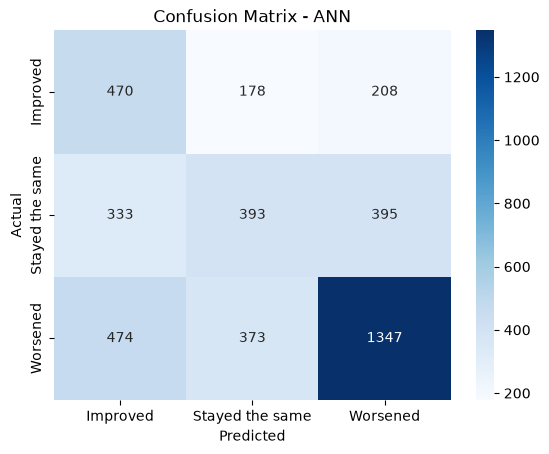

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Get predicted probabilities, then convert to class labels
y_pred_probs = model.predict([county_test, other_test])
y_pred = np.argmax(y_pred_probs, axis=1)

# Weighted F1: primary metric per the problem statement
weighted_f1 = f1_score(y_test_encoded, y_pred, average='weighted')
print(f"Weighted F1-score: {weighted_f1:.4f}")

# Full classification report: precision/recall/F1 per class
print(classification_report(y_test_encoded, y_pred, target_names=target_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - ANN')
plt.show()

In [30]:
print(cm)

[[ 470  178  208]
 [ 333  393  395]
 [ 474  373 1347]]


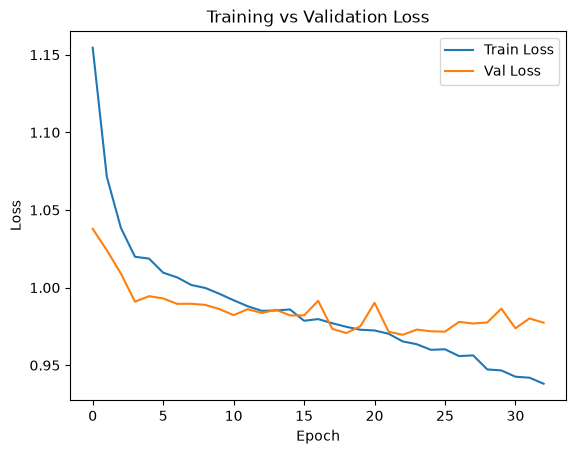

In [31]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

## Data Visualization
Charts, graphs, and plots of the data will be added here.